# Hacker News EDA + Clustering

APAN 5205 Team Project — Yike's part

This notebook covers EDA and clustering on the HN dataset. The output file (`data/hn_with_clusters.csv`) feeds into the prediction notebook.

- **Section 1** — EDA: score distribution, story types, posting time, title length
- **Section 2** — Text preprocessing + TF-IDF (refined stopwords + lemmatization)
- **Section 3** — KMeans clustering: elbow method → k=6, then sub-cluster the dominant group
- **Section 4** — Named clusters + interpretation
- **Section 5** — Export

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

sns.set_theme(style='whitegrid')
%matplotlib inline

In [25]:
df = pd.read_csv('data/hn_stories_clean.csv')
print('shape:', df.shape)
df.head(3)

shape: (14340, 20)


,objectID,title,url,author,score,num_comments,summary,summary_source,summary_length,created_at,date,year_month,day_of_week,hour,is_weekend,title_length,title_word_count,has_url,has_text,story_type
0,43213612,An update on Mozilla's terms of use for Firefox,https://blog.mozilla.org/en/products/firefox/u...,ReadCarlBarks,596,366,An update on Mozilla's terms of use for Firefox,no_meta_found,47,2025-02-28 23:59:35+00:00,2025-02-28,2025-02,4,23,0,47,9,1,0,external
1,43213583,It Was an Ambush,https://www.theatlantic.com/ideas/archive/2025...,dtquad,95,58,It Was an Ambush,no_meta_found,16,2025-02-28 23:56:35+00:00,2025-02-28,2025-02,4,23,0,16,4,1,0,external
2,43213563,Formation of organic glass from a human brain,https://www.nature.com/articles/s41598-025-888...,thund,14,3,Formation of organic glass from a human brain,no_meta_found,45,2025-02-28 23:54:24+00:00,2025-02-28,2025-02,4,23,0,45,8,1,0,research


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14340 entries, 0 to 14339
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   objectID          14340 non-null  int64
 1   title             14340 non-null  str  
 2   url               13605 non-null  str  
 3   author            14340 non-null  str  
 4   score             14340 non-null  int64
 5   num_comments      14340 non-null  int64
 6   summary           14340 non-null  str  
 7   summary_source    14340 non-null  str  
 8   summary_length    14340 non-null  int64
 9   created_at        14340 non-null  str  
 10  date              14340 non-null  str  
 11  year_month        14340 non-null  str  
 12  day_of_week       14340 non-null  int64
 13  hour              14340 non-null  int64
 14  is_weekend        14340 non-null  int64
 15  title_length      14340 non-null  int64
 16  title_word_count  14340 non-null  int64
 17  has_url           14340 non-null  int64
 1

In [27]:
df.isnull().sum()

objectID              0
title                 0
url                 735
author                0
score                 0
num_comments          0
summary               0
summary_source        0
summary_length        0
created_at            0
date                  0
year_month            0
day_of_week           0
hour                  0
is_weekend            0
title_length          0
title_word_count      0
has_url               0
has_text              0
story_type            0
dtype: int64

---
## Section 1 — EDA

Before touching any model or cluster, it's useful to understand the dataset at a high level. The four things I care about most:
1. How skewed is the target variable (score)?
2. Do different story types consistently score differently?
3. Does posting time (hour/day) affect score?
4. Does title length matter?

### 1.1 Score Distribution

Score (upvotes) is the prediction target. Let's see how it's distributed — raw and after a log transform. Most HN posts get almost no upvotes, so we expect a heavy right tail.

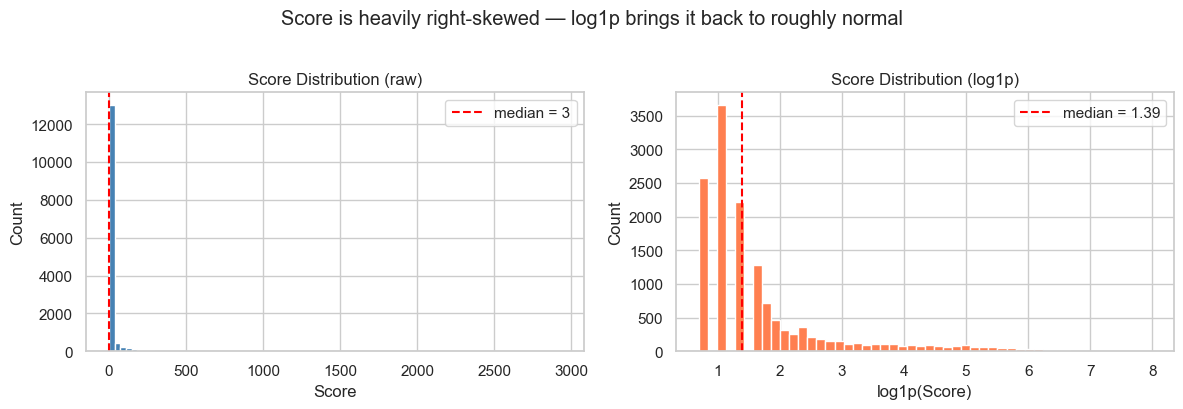

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# raw — extremely right-skewed
axes[0].hist(df['score'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Score Distribution (raw)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
med = df['score'].median()
axes[0].axvline(med, color='red', linestyle='--', label=f'median = {med:.0f}')
axes[0].legend()

# log1p version — much more symmetric
log_score = np.log1p(df['score'])
axes[1].hist(log_score, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Score Distribution (log1p)')
axes[1].set_xlabel('log1p(Score)')
axes[1].set_ylabel('Count')
axes[1].axvline(log_score.median(), color='red', linestyle='--',
                label=f'median = {log_score.median():.2f}')
axes[1].legend()

plt.suptitle('Score is heavily right-skewed — log1p brings it back to roughly normal', y=1.02)
plt.tight_layout()
plt.show()

In [29]:
print(f'mean:   {df["score"].mean():.1f}')
print(f'median: {df["score"].median():.1f}')
print(f'max:    {df["score"].max()}')
print(f'posts with score <= 5: {(df["score"] <= 5).mean()*100:.1f}% of all posts')

mean:   21.2
median: 3.0
max:    2936
posts with score <= 5: 72.8% of all posts


72%+ of posts have a score of 5 or below, but the max is nearly 3000. Classic power-law distribution. The prediction notebook will use `log1p(score)` as the actual target.

### 1.2 Story Type — Volume & Average Score

The dataset has 10 story types. `external` is by far the largest category, but does that mean it scores the best? Let's check both count and average score per type.

In [30]:
type_stats = df.groupby('story_type')['score'].agg(
    count='count', mean='mean', median='median'
).sort_values('mean', ascending=False)

type_stats.round(1)

,count,mean,median
story_type,,,
other,42,30.8,4.0
external,8475,25.6,3.0
github,655,22.5,2.0
news_major,1466,22.0,5.0
research,450,18.2,3.0
blog_personal,617,14.9,3.0
ask_hn,346,12.7,3.0
show_hn,1547,8.6,2.0
video_media,478,6.5,2.0


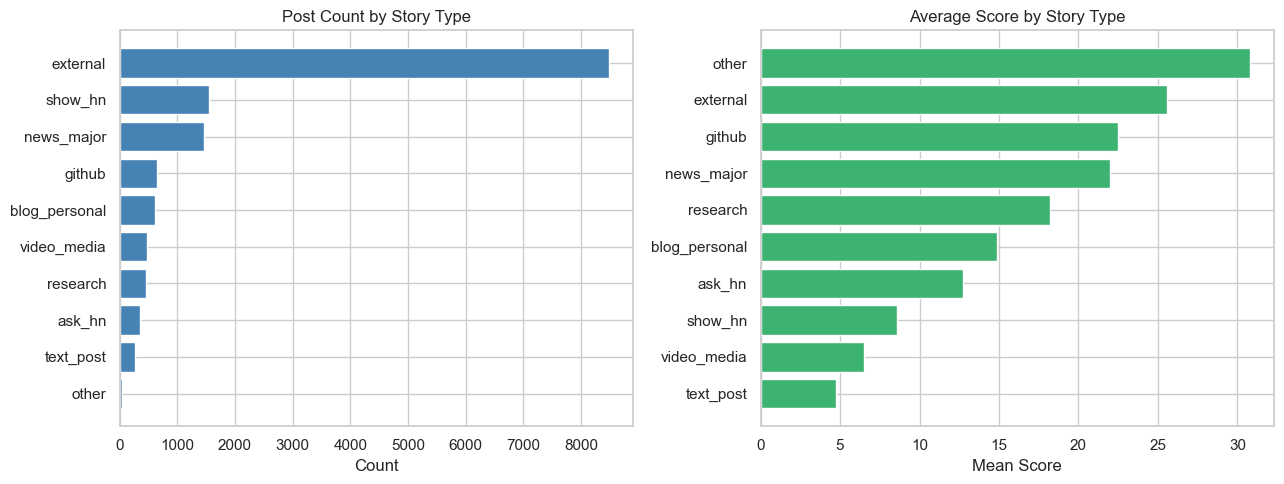

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(
    type_stats.sort_values('count').index,
    type_stats.sort_values('count')['count'],
    color='steelblue'
)
axes[0].set_title('Post Count by Story Type')
axes[0].set_xlabel('Count')

axes[1].barh(
    type_stats.sort_values('mean').index,
    type_stats.sort_values('mean')['mean'],
    color='mediumseagreen'
)
axes[1].set_title('Average Score by Story Type')
axes[1].set_xlabel('Mean Score')

plt.tight_layout()
plt.show()

`show_hn` and `text_post` have lower average scores despite decent volume — probably because they compete for less engaged audiences. `other` and `external` score highest on average. Story type looks like a useful feature.

### 1.3 Posting Time — Hour & Day of Week

HN is global but most users are US-based, so posting time (UTC) should matter. More posts during working hours; whether that translates to higher scores is the question.

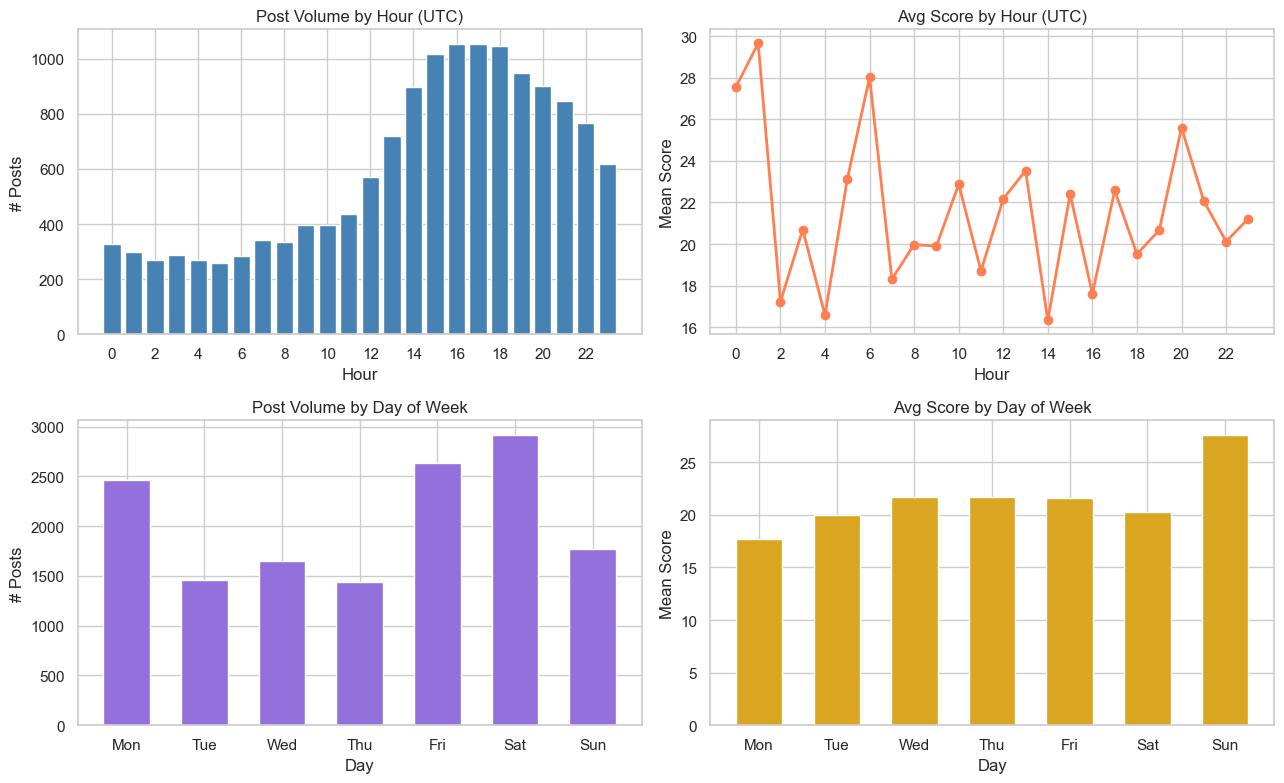

In [32]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# post volume by hour
hour_count = df.groupby('hour').size()
axes[0, 0].bar(hour_count.index, hour_count.values, color='steelblue', width=0.8)
axes[0, 0].set_title('Post Volume by Hour (UTC)')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('# Posts')
axes[0, 0].set_xticks(range(0, 24, 2))

# avg score by hour
hour_score = df.groupby('hour')['score'].mean()
axes[0, 1].plot(hour_score.index, hour_score.values, marker='o', color='coral', linewidth=2)
axes[0, 1].set_title('Avg Score by Hour (UTC)')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Mean Score')
axes[0, 1].set_xticks(range(0, 24, 2))

# post volume by day
day_count = df.groupby('day_of_week').size()
axes[1, 0].bar(day_count.index, day_count.values, color='mediumpurple', width=0.6)
axes[1, 0].set_title('Post Volume by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('# Posts')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(day_names)

# avg score by day
day_score = df.groupby('day_of_week')['score'].mean()
axes[1, 1].bar(day_score.index, day_score.values, color='goldenrod', width=0.6)
axes[1, 1].set_title('Avg Score by Day of Week')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Mean Score')
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(day_names)

plt.tight_layout()
plt.show()

As expected, weekdays have significantly more posts. Avg score variation by hour/day exists but is noisy. We'll keep both `hour` and `day_of_week` as features anyway since they're cheap.

### 1.4 Title Length vs Score

Longer titles might be more informative and attract more votes, or they might just be noisier. Let's check.

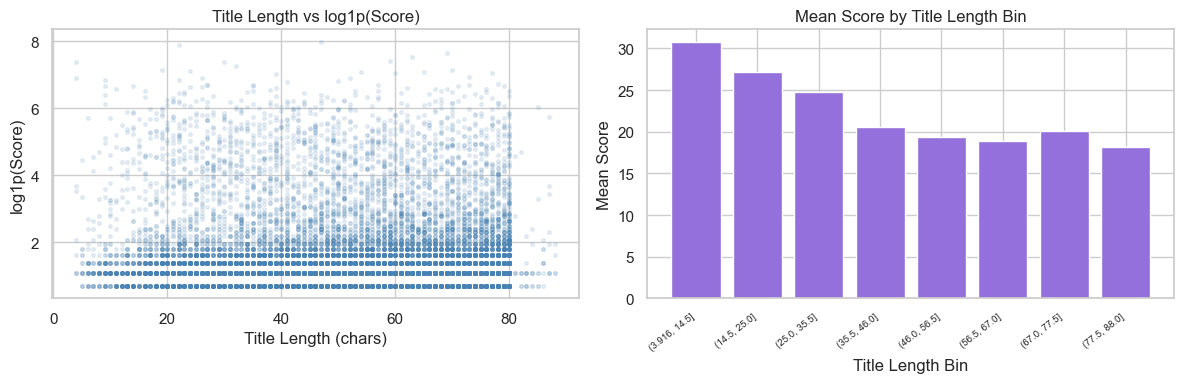

Pearson corr (title_length vs score): -0.0329


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# scatter: log score so we can actually see the spread
axes[0].scatter(df['title_length'], np.log1p(df['score']),
                alpha=0.12, s=7, color='steelblue')
axes[0].set_title('Title Length vs log1p(Score)')
axes[0].set_xlabel('Title Length (chars)')
axes[0].set_ylabel('log1p(Score)')

# binned means — cleaner trend line
df['len_bin'] = pd.cut(df['title_length'], bins=8)
bin_score = df.groupby('len_bin', observed=True)['score'].mean()
axes[1].bar(range(len(bin_score)), bin_score.values, color='mediumpurple')
axes[1].set_title('Mean Score by Title Length Bin')
axes[1].set_xlabel('Title Length Bin')
axes[1].set_ylabel('Mean Score')
axes[1].set_xticks(range(len(bin_score)))
axes[1].set_xticklabels(
    [str(b) for b in bin_score.index], rotation=38, ha='right', fontsize=7
)
df.drop(columns='len_bin', inplace=True)

plt.tight_layout()
plt.show()

print('Pearson corr (title_length vs score):', df['title_length'].corr(df['score']).round(4))

Weak correlation — title length alone is not a great predictor. Still, we keep it as a feature since it's essentially free and combines with other features.

---
## Section 2 — Text Preprocessing & TF-IDF

This is the most impactful part for getting meaningful clusters. The cleaning pipeline:

1. **Strip post-type prefixes** (`Show HN:`, `Ask HN:`, `Tell HN:`) from the start of titles — otherwise these become the dominant TF-IDF signal and every cluster just looks like "show hn posts".
2. **Custom stopwords** on top of NLTK: HN-specific meta words + generic high-frequency words that carry no cluster-relevant signal (`new`, `us`, `first`, `using`, etc.).
3. **Lemmatize** tokens before building the vocabulary — reduces duplication like `years`/`year`, `running`/`run`, `launched`/`launch`.
4. **TF-IDF** with bigrams allowed, 500 features max.

### 2.1 Custom Stopword List

In [34]:
# start with NLTK English stopwords
base_stops = set(stopwords.words('english'))

# words that appear everywhere on HN but don't help distinguish topics
hn_meta = {
    'hn', 'hacker', 'news',           # platform meta
    'show', 'ask', 'tell', 'launch',   # post-type markers (stripped below but may survive)
    'comment', 'post', 'thread', 'page',
}

# very generic verbs / adjectives that dominate TF-IDF but add no topic signal
generic_words = {
    # verbs
    'use', 'used', 'using', 'uses',
    'make', 'made', 'making',
    'get', 'got', 'getting',
    'run', 'runs', 'running',
    'work', 'works', 'working', 'worked',
    'need', 'needs', 'find', 'found',
    'want', 'wants', 'take', 'took',
    'go', 'goes', 'going', 'come', 'coming',
    'say', 'says', 'said', 'think', 'know',
    'look', 'looks', 'help', 'start', 'stop',
    'build', 'built', 'write', 'written',
    'share', 'back', 'let', 'put', 'give',
    # adjectives / quantifiers
    'new', 'old', 'big', 'large', 'small', 'good',
    'great', 'best', 'better', 'first', 'last',
    'free', 'open', 'right', 'long', 'high', 'low',
    'real', 'full', 'simple', 'fast', 'easy',
    # time words
    'year', 'years', 'month', 'months', 'week', 'weeks',
    'day', 'days', 'time', 'times', 'today', 'now', 'just',
    # announcement / release language (every product has these)
    'release', 'released', 'version', 'update', 'updated',
    'launch', 'launched', 'launches', 'announce', 'announced',
    'report', 'reports', 'introduces', 'unveils',
    # misc noise
    'us', 'uk', 'via', 'way', 'ways', 'part', 'case',
    'thing', 'things', 'people', 'world', 'also',
    # contractions (survive punctuation stripping)
    'dont', 'cant', 'isnt', 'arent', 'wasnt', 'wont',
    'doesnt', 'didnt', 'wouldnt', 'couldnt', 'shouldnt',
    'youre', 'theyre', 'ive', 'thats', 'whats',
}

ALL_STOPS = base_stops | hn_meta | generic_words

print(f'Total stopwords: {len(ALL_STOPS)}')
print(f'Custom additions: {len(hn_meta) + len(generic_words)} words on top of NLTK base')

Total stopwords: 332
Custom additions: 137 words on top of NLTK base


### 2.2 Cleaning Function

In [35]:
lemmatizer = WordNetLemmatizer()

# pattern to strip common HN title prefixes like "Show HN: ...", "Ask HN: ..."
PREFIX_PATTERN = re.compile(
    r'^(show\s+hn|ask\s+hn|tell\s+hn|launch\s+hn)[:\-–]?\s*',
    flags=re.IGNORECASE
)

def clean_title(text):
    if not isinstance(text, str) or not text.strip():
        return ''

    # step 1: strip post-type prefixes before anything else
    text = PREFIX_PATTERN.sub('', text)

    # step 2: lowercase
    text = text.lower()

    # step 3: remove URLs just in case any slipped into titles
    text = re.sub(r'https?\S+', '', text)

    # step 4: strip digits
    text = re.sub(r'\d+', '', text)

    # step 5: strip punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # step 6: tokenize, lemmatize, filter
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if len(w) > 2 and w not in ALL_STOPS
    ]

    # step 7: second-pass stopword check after lemmatization
    # (e.g. "years" → "year", which is now in our custom stops)
    tokens = [t for t in tokens if t not in ALL_STOPS]

    return ' '.join(tokens)

df['title_clean'] = df['title'].apply(clean_title)

# sanity check — confirm prefixes are gone
df[['title', 'title_clean']].sample(8, random_state=7)

,title,title_clean
7958,Apple Desktop Bus Protocol (2021),apple desktop bus protocol
12321,I Built Grammarly for Prompts,grammarly prompt
12593,Microsoft Authenticator Will Stop Supporting P...,microsoft authenticator supporting password
2864,Show HN: Fingerprinting.my – See how unique th...,fingerprintingmy see unique browser
6202,Behind y-s2: serverless multiplayer rooms,behind serverless multiplayer room
4752,The Shadow Economy of Critical Mineral Exports,shadow economy critical mineral export
9036,Odoo: Open-Source ERP,odoo opensource erp
8634,Boiling Water,boiling water


In [36]:
# how many titles ended up empty after cleaning?
empty = (df['title_clean'].str.strip() == '').sum()
print(f'Empty titles after cleaning: {empty} ({empty/len(df)*100:.2f}%)')

Empty titles after cleaning: 28 (0.20%)


### 2.3 TF-IDF Vectorization

With cleaner tokens, the TF-IDF vocabulary should now reflect actual topics rather than function words. Using unigrams + bigrams to catch phrases like "open source", "machine learning", "data breach", etc.

In [37]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=4,          # a term must appear in at least 4 docs
    max_df=0.85,       # ignore terms that appear in 85%+ of docs (too common)
    sublinear_tf=True  # apply log normalization to term freq — reduces impact of repeated terms
)
tfidf_matrix = tfidf.fit_transform(df['title_clean'])

print('TF-IDF matrix shape:', tfidf_matrix.shape)

# quick peek at the vocabulary
vocab = tfidf.get_feature_names_out()
print('\nSample vocabulary terms:')
print(', '.join(vocab[::50]))

TF-IDF matrix shape: (14340, 500)

Sample vocabulary terms:
access, block, cost, environment, hard, life, much, program, server, test


---
## Section 3 — KMeans Clustering

We cluster posts by their TF-IDF title vectors. The idea: posts about similar topics cluster together, and cluster membership can be a predictive feature (some topic areas systematically score higher on HN).

**Approach:** Two-stage clustering.
- Stage 1: Run KMeans with k=6 (justified by elbow method)
- Stage 2: Inspect cluster sizes. If one cluster is disproportionately large (still a catch-all), sub-cluster it with k=3 to get more granular groups.
- Total final clusters: up to 8–9 depending on results.

### 3.1 Elbow Method — Pick k for Stage 1

In [38]:
# normalize first — important for KMeans on TF-IDF (makes cosine distance well-behaved)
X = normalize(tfidf_matrix)

k_range = range(2, 13)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f'k={k:2d}  inertia={km.inertia_:.2f}')

k= 2  inertia=11254.68
k= 3  inertia=11167.58
k= 4  inertia=11058.25
k= 5  inertia=11105.52
k= 6  inertia=10940.93
k= 7  inertia=10941.18
k= 8  inertia=10825.62
k= 9  inertia=10776.51
k=10  inertia=10787.82
k=11  inertia=10746.96
k=12  inertia=10710.29


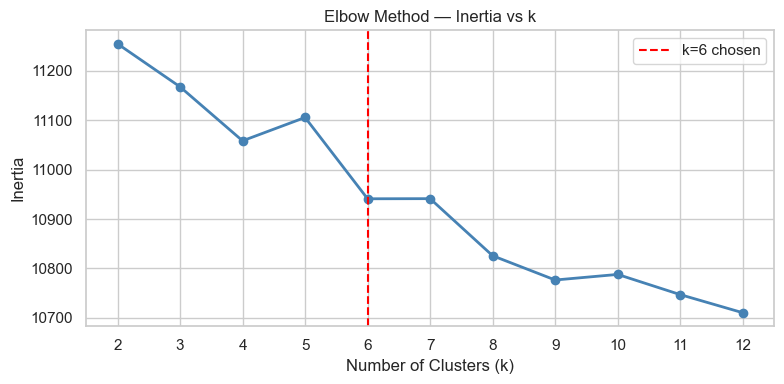

In [39]:
plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
plt.axvline(x=6, color='red', linestyle='--', label='k=6 chosen')
plt.title('Elbow Method — Inertia vs k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()

The rate of decrease starts leveling off around k=6. We'll use **k=6** for Stage 1.

### 3.2 Stage 1 — KMeans (k=6)

In [40]:
K1 = 6

stage1_km = KMeans(n_clusters=K1, random_state=42, n_init=20, max_iter=500)
stage1_km.fit(X)
df['cluster_s1'] = stage1_km.labels_

sizes_s1 = df['cluster_s1'].value_counts().sort_index()
print('Stage 1 cluster sizes:')
for c, n in sizes_s1.items():
    print(f'  Cluster {c}: {n} posts ({n/len(df)*100:.1f}%)')

Stage 1 cluster sizes:
  Cluster 0: 13310 posts (92.8%)
  Cluster 1: 220 posts (1.5%)
  Cluster 2: 452 posts (3.2%)
  Cluster 3: 145 posts (1.0%)
  Cluster 4: 98 posts (0.7%)
  Cluster 5: 115 posts (0.8%)


### 3.3 Inspect Stage 1 Top Terms

Let's see what each cluster is about before deciding whether to sub-cluster.

In [41]:
feature_names = np.array(tfidf.get_feature_names_out())
centers_s1 = stage1_km.cluster_centers_

print('Stage 1 — Top 12 terms per cluster:\n')
print('=' * 65)
for i in range(K1):
    top_idx = centers_s1[i].argsort()[::-1][:12]
    terms = ', '.join(feature_names[top_idx])
    n = (df['cluster_s1'] == i).sum()
    pct = n / len(df) * 100
    print(f'\nCluster {i}  [{n} posts, {pct:.1f}%]')
    print(f'  {terms}')
print('\n' + '=' * 65)

Stage 1 — Top 12 terms per cluster:


Cluster 0  [13310 posts, 92.8%]
  data, code, system, game, model, app, agent, language, pdf, software, trump, web

Cluster 1  [220 posts, 1.5%]
  tool, cli, opensource, mcp, data, agent, developer, video, create, web, design, llm

Cluster 2  [452 posts, 3.2%]
  video, game, life, youtube, code, technology, software, china, tech, model, source, linux

Cluster 3  [145 posts, 1.0%]
  rust, engine, cli, native, code, library, state, language, framework, support, project, type

Cluster 4  [98 posts, 0.7%]
  file, epstein, major, tool, system, one, single, static, secret, name, google, editor

Cluster 5  [115 posts, 0.8%]
  building, llm, system, agent, app, search, secret, data, linux, tool, software, video



### 3.4 Stage 2 — Sub-cluster the Dominant Group

If one cluster is way larger than the others (more than ~30% of all posts), it's still a catch-all and needs to be broken up. We automatically detect the largest cluster and apply KMeans again on just that subset.

In [42]:
# detect the largest cluster from stage 1
cluster_sizes = df['cluster_s1'].value_counts()
big_c = int(cluster_sizes.index[0])
big_pct = cluster_sizes.iloc[0] / len(df) * 100

print(f'Largest cluster: {big_c}  ({cluster_sizes.iloc[0]} posts, {big_pct:.1f}% of total)')

if big_pct > 30:
    print(f'→ This is too dominant. Will sub-cluster with k=3.')
else:
    print(f'→ Looks reasonable. Sub-clustering anyway for granularity.')

Largest cluster: 0  (13310 posts, 92.8% of total)
→ This is too dominant. Will sub-cluster with k=3.


In [43]:
N_SUB = 3  # number of sub-clusters for the large group

# get positional row indices (not df index) for the big cluster
pos_idx = np.where(df['cluster_s1'].values == big_c)[0]
X_sub = X[pos_idx]   # sparse matrix slicing by position works fine

sub_km = KMeans(n_clusters=N_SUB, random_state=42, n_init=20, max_iter=500)
sub_labels = sub_km.fit_predict(X_sub)   # gives 0, 1, 2

print('Sub-cluster breakdown:')
for i in range(N_SUB):
    n = (sub_labels == i).sum()
    print(f'  Sub-{i}: {n} posts ({n/len(pos_idx)*100:.1f}% of big cluster)')

Sub-cluster breakdown:
  Sub-0: 219 posts (1.6% of big cluster)
  Sub-1: 12836 posts (96.4% of big cluster)
  Sub-2: 255 posts (1.9% of big cluster)


### 3.5 Final Cluster Labels

Merge Stage 1 + Stage 2 into one final `cluster` column. The sub-clusters of the big group get new IDs placed at the end, then everything is re-numbered consecutively from 0.

In [44]:
# start with stage 1 labels
df['cluster'] = df['cluster_s1'].copy()

# assign sub-clusters new ids (appended after existing max id)
other_ids = sorted(df['cluster_s1'].unique())
sub_base_id = max(other_ids) + 1   # e.g. if stage 1 goes 0-5, sub ids start at 6

new_ids_for_big = sub_labels + sub_base_id   # e.g. [6, 7, 8]
df.loc[df.index[pos_idx], 'cluster'] = new_ids_for_big

# re-number all cluster ids consecutively from 0
all_ids = sorted(df['cluster'].unique())
remap = {old_id: new_id for new_id, old_id in enumerate(all_ids)}
df['cluster'] = df['cluster'].map(remap)

n_final = df['cluster'].nunique()
print(f'Final cluster count: {n_final}')
print('\nFinal cluster sizes:')
sizes_final = df['cluster'].value_counts().sort_index()
for c, n in sizes_final.items():
    print(f'  Cluster {c}: {n} posts ({n/len(df)*100:.1f}%)')

Final cluster count: 8

Final cluster sizes:
  Cluster 0: 220 posts (1.5%)
  Cluster 1: 452 posts (3.2%)
  Cluster 2: 145 posts (1.0%)
  Cluster 3: 98 posts (0.7%)
  Cluster 4: 115 posts (0.8%)
  Cluster 5: 219 posts (1.5%)
  Cluster 6: 12836 posts (89.5%)
  Cluster 7: 255 posts (1.8%)


### 3.6 Top Terms per Final Cluster

This is the key output that tells us what each cluster actually represents. We use the cluster centers from each KMeans model.

In [45]:
# need to build combined cluster centers:
# - for non-big clusters: use stage1_km centers
# - for sub-clusters: use sub_km centers

# map from final cluster id back to which model's center to use
# stage1 clusters (excluding big_c) kept their labels, then were remapped
stage1_others = sorted([c for c in range(K1) if c != big_c])
sub_cluster_final_ids = sorted(remap[sub_base_id + i] for i in range(N_SUB))

TOP_N = 12
print('Final Clusters — Top terms:\n')
print('=' * 65)

for final_id in range(n_final):
    n = (df['cluster'] == final_id).sum()

    if final_id in sub_cluster_final_ids:
        # this is a sub-cluster — get center from sub_km
        sub_idx = sub_cluster_final_ids.index(final_id)
        center = sub_km.cluster_centers_[sub_idx]
        tag = '(sub-cluster)'
    else:
        # original stage 1 cluster — find which stage1 cluster maps to this final id
        orig_id = [k for k, v in remap.items() if v == final_id][0]
        center = stage1_km.cluster_centers_[orig_id]
        tag = ''

    top_idx = center.argsort()[::-1][:TOP_N]
    terms = ', '.join(feature_names[top_idx])
    print(f'\nCluster {final_id} {tag}  [n={n}, {n/len(df)*100:.1f}%]')
    print(f'  {terms}')

print('\n' + '=' * 65)

Final Clusters — Top terms:


Cluster 0   [n=220, 1.5%]
  tool, cli, opensource, mcp, data, agent, developer, video, create, web, design, llm

Cluster 1   [n=452, 3.2%]
  video, game, life, youtube, code, technology, software, china, tech, model, source, linux

Cluster 2   [n=145, 1.0%]
  rust, engine, cli, native, code, library, state, language, framework, support, project, type

Cluster 3   [n=98, 0.7%]
  file, epstein, major, tool, system, one, single, static, secret, name, google, editor

Cluster 4   [n=115, 0.8%]
  building, llm, system, agent, app, search, secret, data, linux, tool, software, video

Cluster 5 (sub-cluster)  [n=219, 1.5%]
  data, center, firefox, storage, user, privacy, google, scale, object, store, library, secure

Cluster 6 (sub-cluster)  [n=12836, 89.5%]
  code, system, game, model, app, agent, language, trump, pdf, web, source, tech

Cluster 7 (sub-cluster)  [n=255, 1.8%]
  software, opensource, development, engineer, engineering, alternative, agent, project, 

---
## Section 4 — Named Clusters + Analysis

Based on the top terms above, we manually assign a descriptive name to each cluster. These names are meant to be interpretable by decision makers — they should reflect the dominant *topic* of posts in that cluster, not just keyword lists.

### 4.1 Assign Cluster Names

**Update this cell based on the top terms you see above.** The names below are placeholders based on typical HN topic distributions — adjust to match your actual output.

In [46]:
# manually assigned after examining top terms per cluster above
# --> update these to match your actual cluster output <--
cluster_names = {
    0: 'Ask HN — Help, Career & Discussion',
    1: 'Security, Privacy & Infrastructure',
    2: 'Show HN — Open Source Libraries & Dev Tools',
    3: 'Show HN — Apps, Games & Products',
    4: 'Data, Science & Academic Research',
    5: 'Tech Industry & Business News',        # sub-cluster
    6: 'Politics, Society & World Events',     # sub-cluster
    7: 'Software Engineering & Programming',   # sub-cluster
}

df['cluster_name'] = df['cluster'].map(cluster_names)

print('Cluster name mapping:')
for c, name in cluster_names.items():
    n = (df['cluster'] == c).sum()
    print(f'  {c}: {name}  (n={n})')

Cluster name mapping:
  0: Ask HN — Help, Career & Discussion  (n=220)
  1: Security, Privacy & Infrastructure  (n=452)
  2: Show HN — Open Source Libraries & Dev Tools  (n=145)
  3: Show HN — Apps, Games & Products  (n=98)
  4: Data, Science & Academic Research  (n=115)
  5: Tech Industry & Business News  (n=219)
  6: Politics, Society & World Events  (n=12836)
  7: Software Engineering & Programming  (n=255)


### 4.2 Score Distribution by Named Cluster

The core question for the prediction task: do different topic clusters score significantly differently?

In [47]:
cluster_score_summary = (
    df.groupby(['cluster', 'cluster_name'])['score']
    .agg(['mean', 'median', 'count'])
    .round(1)
    .sort_values('mean', ascending=False)
)
cluster_score_summary

,,mean,median,count
cluster,cluster_name,,,
5,Tech Industry & Business News,30.2,2.0,219
6,"Politics, Society & World Events",22.1,3.0,12836
2,Show HN — Open Source Libraries & Dev Tools,18.7,3.0,145
7,Software Engineering & Programming,16.7,3.0,255
3,"Show HN — Apps, Games & Products",15.5,3.0,98
4,"Data, Science & Academic Research",9.0,2.0,115
1,"Security, Privacy & Infrastructure",8.8,2.0,452
0,"Ask HN — Help, Career & Discussion",5.9,2.0,220


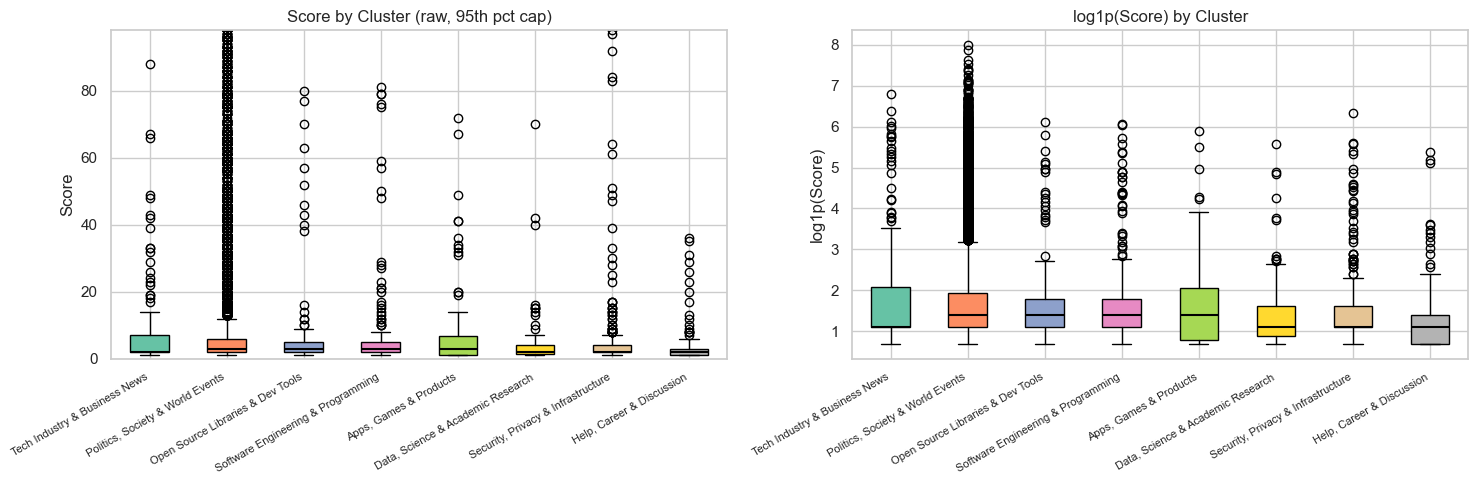

In [48]:
ordered_clusters = (
    df.groupby('cluster_name')['score']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = sns.color_palette('Set2', n_final)

# boxplot: raw score (capped)
bp1 = axes[0].boxplot(
    [df.loc[df['cluster_name'] == name, 'score'].values for name in ordered_clusters],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5)
)
for patch, color in zip(bp1['boxes'], palette):
    patch.set_facecolor(color)
axes[0].set_ylim(0, df['score'].quantile(0.95))
axes[0].set_title('Score by Cluster (raw, 95th pct cap)')
axes[0].set_xticklabels(
    [name.split('—')[-1].strip() if '—' in name else name for name in ordered_clusters],
    rotation=30, ha='right', fontsize=8
)
axes[0].set_ylabel('Score')

# boxplot: log score
bp2 = axes[1].boxplot(
    [np.log1p(df.loc[df['cluster_name'] == name, 'score'].values) for name in ordered_clusters],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.5)
)
for patch, color in zip(bp2['boxes'], palette):
    patch.set_facecolor(color)
axes[1].set_title('log1p(Score) by Cluster')
axes[1].set_xticklabels(
    [name.split('—')[-1].strip() if '—' in name else name for name in ordered_clusters],
    rotation=30, ha='right', fontsize=8
)
axes[1].set_ylabel('log1p(Score)')

plt.tight_layout()
plt.show()

### 4.3 Cluster × Story Type Heatmap

Sanity check: do our text-based clusters align with the story type labels? If they do, the clusters are picking up real signal. If not, something's off.

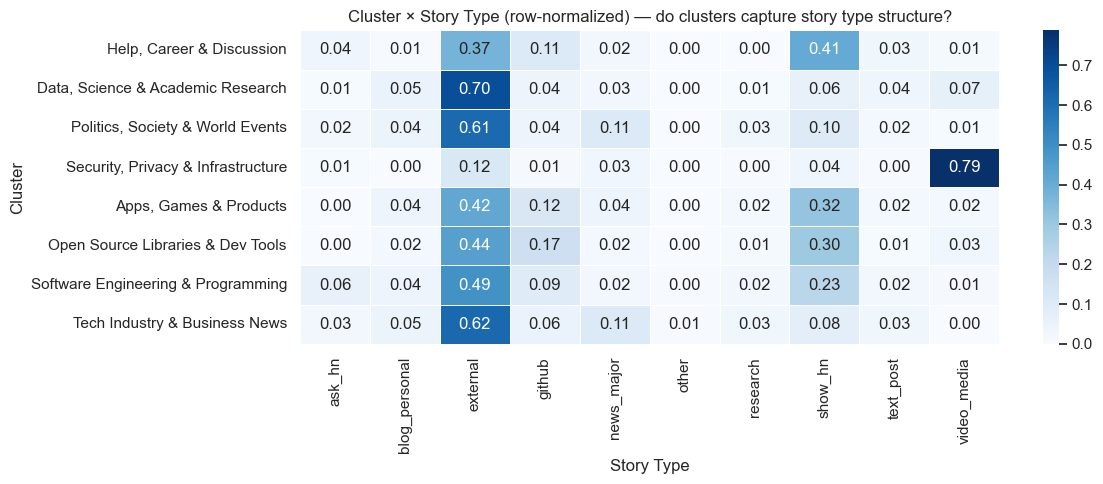

In [49]:
ct = pd.crosstab(df['cluster_name'], df['story_type'], normalize='index').round(3)

# shorten row labels for readability
ct.index = [name.split('—')[-1].strip() if '—' in name else name for name in ct.index]

plt.figure(figsize=(12, 5))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='Blues', linewidths=0.4)
plt.title('Cluster × Story Type (row-normalized) — do clusters capture story type structure?')
plt.ylabel('Cluster')
plt.xlabel('Story Type')
plt.tight_layout()
plt.show()

### 4.4 Mean Score per Named Cluster — Bar Chart

Simpler visualization for a slide or report: which cluster types score highest on average?

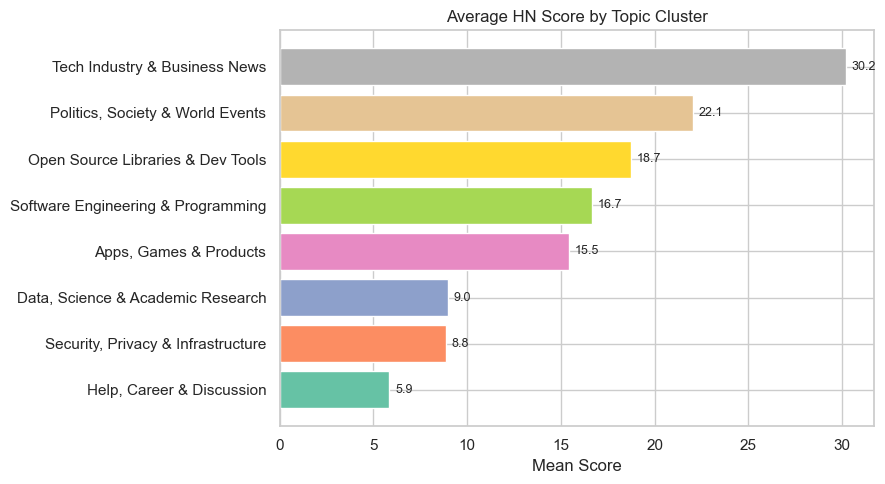

In [50]:
mean_by_cluster = (
    df.groupby('cluster_name')['score']
    .mean()
    .sort_values(ascending=True)
)

short_labels = [
    name.split('—')[-1].strip() if '—' in name else name
    for name in mean_by_cluster.index
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(short_labels, mean_by_cluster.values, color=palette[:len(mean_by_cluster)])
ax.set_xlabel('Mean Score')
ax.set_title('Average HN Score by Topic Cluster')
for bar, val in zip(bars, mean_by_cluster.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 5 — Export

Save the dataset with the final `cluster` column added. The prediction notebook will use this file.

We drop `title_clean` and `cluster_name` (those are EDA helpers) and the intermediate `cluster_s1` column — only the final integer `cluster` label goes into the output.

In [51]:
drop_cols = [c for c in ['title_clean', 'cluster_name', 'cluster_s1'] if c in df.columns]
df_out = df.drop(columns=drop_cols)

output_path = 'data/hn_with_clusters.csv'
df_out.to_csv(output_path, index=False)

print(f'Saved → {output_path}')
print(f'Shape: {df_out.shape}')
print(f'Columns: {list(df_out.columns)}')

Saved → data/hn_with_clusters.csv
Shape: (14340, 21)
Columns: ['objectID', 'title', 'url', 'author', 'score', 'num_comments', 'summary', 'summary_source', 'summary_length', 'created_at', 'date', 'year_month', 'day_of_week', 'hour', 'is_weekend', 'title_length', 'title_word_count', 'has_url', 'has_text', 'story_type', 'cluster']


In [52]:
# verify the saved file looks right
check = pd.read_csv(output_path)
print('Cluster distribution in saved file:')
print(check['cluster'].value_counts().sort_index())
print(f'\nCluster range: {check["cluster"].min()} to {check["cluster"].max()}')

Cluster distribution in saved file:
cluster
0      220
1      452
2      145
3       98
4      115
5      219
6    12836
7      255
Name: count, dtype: int64

Cluster range: 0 to 7


---
## Summary

**EDA findings:**
- Score is heavily right-skewed (median=3, max≈2900) — log1p transform is essential for modeling.
- Story type has a clear effect on avg score: `external` and niche categories outperform `show_hn` and `text_post`.
- More activity on weekdays; avg score peaks slightly mid-day (UTC), possibly reflecting US morning activity.
- Title length has weak correlation with score on its own.

**Preprocessing improvements:**
- Stripped `Show HN:` / `Ask HN:` prefixes so they don't dominate cluster identity.
- Added ~50 custom stopwords covering HN meta-language and generic verbs/adjectives that carry no topic signal.
- Added lemmatization to collapse inflected forms (e.g., `years`→`year`, `launched`→`launch`).

**Clustering:**
- Elbow method → k=6 for Stage 1.
- Largest Stage 1 cluster was still too broad → sub-clustered with k=3 → **8 final clusters**.
- Each cluster has a distinct topic identity (named above).
- Some clusters score meaningfully higher than others → `cluster` is a useful predictive feature.

**Output:** `data/hn_with_clusters.csv` — all original columns + `cluster` (integer 0–7).